In [7]:
import json
import joblib
from pathlib import Path

import numpy as np
import pandas as pd
import xgboost as xgb

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
)

from scipy.special import expit  # sigmoid
from treehfd import XGBTreeHFD


# ---------------------------------------------------------------------
# Config
# ---------------------------------------------------------------------
DATA_PATH = Path(
    "./preprocessed_datasets/"
    "dataset_alpha_0.1_full_binarytarget_win-24_thresh-15_both_dynamic-False.parquet"
)

OUT_DIR = Path("./trained_models/xgb_random_forest_treehfd_newfeatures")
OUT_DIR.mkdir(parents=True, exist_ok=True)

TARGET_COL = "target"
TIME_COL = "timestamp"

TEST_FRAC = 0.30
VAL_FRAC = 0.15

RANDOM_STATE = 1233
NUM_PARALLEL_TREE = 800
N_ESTIMATORS = 1
MAX_DEPTH = 6

INTERACTION_ORDER = 2


# ---------------------------------------------------------------------
# Load dataset
# ---------------------------------------------------------------------
df = pd.read_parquet(DATA_PATH)

# Match your original pipeline where timestamp comes from the index.
# If your parquet already has a timestamp column and you prefer it,
# replace this line with: df[TIME_COL] = pd.to_datetime(df[TIME_COL])
df[TIME_COL] = df.index

# Recreate lag features
for k in range(1, 8):
    df[f"depeg_bps_lag{k}h"] = df["depeg_bps"].shift(k)

df = df.dropna().copy()

df[TIME_COL] = pd.to_datetime(df[TIME_COL])
df = df.sort_values(TIME_COL).reset_index(drop=True)

if TARGET_COL not in df.columns:
    raise ValueError(f"Target column '{TARGET_COL}' not found in dataset.")

FEATURES = [c for c in df.columns if c not in [TIME_COL, TARGET_COL]]

X = df[FEATURES].copy()
y = df[TARGET_COL].astype(int).copy()

# Convert bool columns to int
bool_cols = X.select_dtypes(include=["bool"]).columns.tolist()
if bool_cols:
    X[bool_cols] = X[bool_cols].astype(int)

# Ensure numeric-only input for XGBoost/TreeHFD
non_numeric_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()
if non_numeric_cols:
    raise ValueError(
        "XGBoost/TreeHFD require numeric features. "
        f"Non-numeric columns found: {non_numeric_cols}"
    )

print(f"Loaded dataset: {DATA_PATH}")
print(f"Rows after lag/dropna: {len(df):,}")
print(f"Number of features: {len(FEATURES):,}")
print("Target distribution:")
print(y.value_counts().sort_index())


# ---------------------------------------------------------------------
# Time-series split: train / validation / test
# ---------------------------------------------------------------------
n = len(df)

test_size = int(TEST_FRAC * n)
val_size = int(VAL_FRAC * n)

test_start = n - test_size
val_start = test_start - val_size

X_train = X.iloc[:val_start].copy()
y_train = y.iloc[:val_start].copy()

X_val = X.iloc[val_start:test_start].copy()
y_val = y.iloc[val_start:test_start].copy()

X_test = X.iloc[test_start:].copy()
y_test = y.iloc[test_start:].copy()

dates_train = df[TIME_COL].iloc[:val_start].reset_index(drop=True)
dates_val = df[TIME_COL].iloc[val_start:test_start].reset_index(drop=True)
dates_test = df[TIME_COL].iloc[test_start:].reset_index(drop=True)

print("\nTime split:")
print(f"Train: {len(X_train):,} rows | {dates_train.min()} -> {dates_train.max()}")
print(f"Val:   {len(X_val):,} rows | {dates_val.min()} -> {dates_val.max()}")
print(f"Test:  {len(X_test):,} rows | {dates_test.min()} -> {dates_test.max()}")

print("\nTrain target distribution:")
print(y_train.value_counts().sort_index())

print("\nValidation target distribution:")
print(y_val.value_counts().sort_index())

print("\nTest target distribution:")
print(y_test.value_counts().sort_index())


# ---------------------------------------------------------------------
# Convert to numpy for TreeHFD compatibility
# ---------------------------------------------------------------------
X_train_np = X_train.to_numpy(dtype=float)
X_val_np = X_val.to_numpy(dtype=float)
X_test_np = X_test.to_numpy(dtype=float)

y_train_np = y_train.to_numpy(dtype=int)
y_val_np = y_val.to_numpy(dtype=int)
y_test_np = y_test.to_numpy(dtype=int)

# Compute scale_pos_weight for XGBoost to handle class imbalance.
n_pos = int((y_train_np == 1).sum())
n_neg = int((y_train_np == 0).sum())
w_pos = float(n_neg / max(n_pos, 1))

# ---------------------------------------------------------------------
# XGBoost random forest classifier
# ---------------------------------------------------------------------
n_features = X_train.shape[1]

# sklearn RandomForestClassifier's default max_features for classification
# is sqrt(n_features). In XGBoost, colsample_bynode is a fraction, so the
# equivalent fraction is sqrt(p) / p = 1 / sqrt(p).
if n_features > 1:
    colsample_bynode = 1.0 / np.sqrt(n_features)
else:
    colsample_bynode = 1.0

xgb_rf = xgb.XGBClassifier(
    # Critical RF-style settings
    n_estimators=N_ESTIMATORS,              # one boosting round
    num_parallel_tree=NUM_PARALLEL_TREE,    # forest size
    learning_rate=0.01,
    max_depth = MAX_DEPTH,
    # Randomization
    subsample=0.8,
    colsample_bynode=colsample_bynode,
    #early-stopping+class imbalance
    early_stopping_rounds=200,
    scale_pos_weight=w_pos,

    # Binary classification
    objective="binary:logistic",
    eval_metric="auc",

    # Tree booster
    booster="gbtree",
    tree_method="hist",

    # Reproducibility / compute
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

xgb_rf.fit(
    X_train_np,
    y_train_np,
    eval_set=[(X_train_np, y_train_np), (X_val_np, y_val_np)],
    verbose=False,
)

print("\nFinished fitting XGBoost random forest.")
print(f"num_parallel_tree: {NUM_PARALLEL_TREE}")
print(f"n_estimators: {N_ESTIMATORS}")
print(f"colsample_bynode: {colsample_bynode:.6f}")


# ---------------------------------------------------------------------
# Evaluation
# ---------------------------------------------------------------------
def evaluate_split(model, X_np, y_np, split_name):
    proba = model.predict_proba(X_np)[:, 1]
    pred = (proba >= 0.5).astype(int)

    metrics = {
        f"{split_name}_roc_auc": float(roc_auc_score(y_np, proba)),
        f"{split_name}_auprc": float(average_precision_score(y_np, proba)),
    }

    report = classification_report(y_np, pred, output_dict=True)
    cm = confusion_matrix(y_np, pred)

    return proba, pred, metrics, report, cm


proba_val, pred_val, val_metrics, val_report, val_cm = evaluate_split(
    xgb_rf,
    X_val_np,
    y_val_np,
    "val",
)

proba_test, pred_test, test_metrics, test_report, test_cm = evaluate_split(
    xgb_rf,
    X_test_np,
    y_test_np,
    "test",
)

metrics = {
    **val_metrics,
    **test_metrics,
    "n_train": int(len(X_train)),
    "n_val": int(len(X_val)),
    "n_test": int(len(X_test)),
    "n_features": int(n_features),
    "num_parallel_tree": int(NUM_PARALLEL_TREE),
    "n_estimators": int(N_ESTIMATORS),
    "learning_rate": 1.0,
    "subsample": 0.8,
    "colsample_bynode": float(colsample_bynode),
}

print("\nMetrics:")
print(json.dumps(metrics, indent=2))


# ---------------------------------------------------------------------
# TreeHFD decomposition
# ---------------------------------------------------------------------
# Fit the decomposition using the training distribution.
# Then compute components on the test set.
#
# For binary logistic XGBoost models, the additive tree model is naturally
# on the margin/logit scale. Therefore, the reconstructed HFD prediction
# below is a margin. Applying sigmoid gives an approximate probability.
print("\nFitting TreeHFD decomposition...")

treehfd_model = XGBTreeHFD(xgb_rf)
treehfd_model.fit(X_train_np, interaction_order=INTERACTION_ORDER)

print("Computing TreeHFD components on test set...")

if INTERACTION_ORDER == 1:
    y_main = treehfd_model.predict(X_test_np)
    y_order2 = None
    hfd_margin = treehfd_model.eta0 + np.sum(y_main, axis=1)
else:
    y_main, y_order2 = treehfd_model.predict(X_test_np)
    # ---------------------------------------------------------------------
    # Save TreeHFD interaction labels
    # ---------------------------------------------------------------------
    if y_order2 is not None:
        interaction_pairs = np.asarray(treehfd_model.interaction_list, dtype=int)

        print(f"TreeHFD interaction_list shape: {interaction_pairs.shape}")
        print(f"y_order2 shape: {y_order2.shape}")

        if interaction_pairs.shape[0] != y_order2.shape[1]:
            raise ValueError(
                "Mismatch between treehfd_model.interaction_list and y_order2. "
                f"interaction_list has {interaction_pairs.shape[0]} rows, "
                f"but y_order2 has {y_order2.shape[1]} columns."
            )

        interaction_label_df = pd.DataFrame(
            {
                "interaction_idx": np.arange(interaction_pairs.shape[0]),
                "feature_i_idx": interaction_pairs[:, 0],
                "feature_j_idx": interaction_pairs[:, 1],
                "feature_i": [FEATURES[i] for i in interaction_pairs[:, 0]],
                "feature_j": [FEATURES[j] for j in interaction_pairs[:, 1]],
            }
        )

        interaction_label_df["interaction"] = (
            interaction_label_df["feature_i"] + " × " + interaction_label_df["feature_j"]
        )

        interaction_label_df.to_csv(
            OUT_DIR / "treehfd_interaction_labels.csv",
            index=False,
        )

        interaction_label_df.to_parquet(
            OUT_DIR / "treehfd_interaction_labels.parquet",
            index=False,
        )

        np.save(
            OUT_DIR / "treehfd_interaction_list.npy",
            interaction_pairs,
        )

        print("Saved TreeHFD interaction labels.")
    hfd_margin = (
        treehfd_model.eta0
        + np.sum(y_main, axis=1)
        + np.sum(y_order2, axis=1)
    )

hfd_proba = expit(hfd_margin)

# XGBoost raw margin for comparison
xgb_margin_test = xgb_rf.predict(X_test_np, output_margin=True)

hfd_resid_margin = xgb_margin_test - hfd_margin
normalized_hfd_mse = float(
    np.mean(hfd_resid_margin ** 2) / np.var(xgb_margin_test)
)

treehfd_metrics = {
    "treehfd_eta0": float(treehfd_model.eta0),
    "treehfd_interaction_order": int(INTERACTION_ORDER),
    "treehfd_normalized_margin_mse": normalized_hfd_mse,
}

print("\nTreeHFD metrics:")
print(json.dumps(treehfd_metrics, indent=2))


# ---------------------------------------------------------------------
# Save artifacts
# ---------------------------------------------------------------------
print("\nSaving artifacts...")

# Model
joblib.dump(xgb_rf, OUT_DIR / "xgb_random_forest.joblib")
xgb_rf.save_model(OUT_DIR / "xgb_random_forest.json")

# TreeHFD object
joblib.dump(treehfd_model, OUT_DIR / "treehfd_model.joblib")

# Features
with open(OUT_DIR / "features.txt", "w") as f:
    f.write("\n".join(FEATURES))

# Metrics
with open(OUT_DIR / "metrics.json", "w") as f:
    json.dump({**metrics, **treehfd_metrics}, f, indent=2)

with open(OUT_DIR / "val_classification_report.json", "w") as f:
    json.dump(val_report, f, indent=2)

with open(OUT_DIR / "test_classification_report.json", "w") as f:
    json.dump(test_report, f, indent=2)

np.save(OUT_DIR / "val_confusion_matrix.npy", val_cm)
np.save(OUT_DIR / "test_confusion_matrix.npy", test_cm)

# Split data metadata
split_metadata = {
    "data_path": str(DATA_PATH),
    "target_col": TARGET_COL,
    "time_col": TIME_COL,
    "features": FEATURES,
    "test_frac": TEST_FRAC,
    "val_frac": VAL_FRAC,
    "train_start": str(dates_train.min()),
    "train_end": str(dates_train.max()),
    "val_start": str(dates_val.min()),
    "val_end": str(dates_val.max()),
    "test_start": str(dates_test.min()),
    "test_end": str(dates_test.max()),
    "model_type": "xgboost.XGBClassifier configured as random forest",
    "xgboost_params": xgb_rf.get_params(),
}

with open(OUT_DIR / "metadata.json", "w") as f:
    json.dump(split_metadata, f, indent=2, default=str)

# Predictions
val_pred_df = pd.DataFrame(
    {
        TIME_COL: dates_val,
        "y_true": y_val_np,
        "proba_depeg": proba_val,
        "pred_0p5": pred_val,
    }
)

test_pred_df = pd.DataFrame(
    {
        TIME_COL: dates_test,
        "y_true": y_test_np,
        "proba_depeg": proba_test,
        "pred_0p5": pred_test,
        "xgb_margin": xgb_margin_test,
        "treehfd_margin": hfd_margin,
        "treehfd_proba": hfd_proba,
        "treehfd_margin_residual": hfd_resid_margin,
    }
)

val_pred_df.to_parquet(OUT_DIR / "val_predictions.parquet", index=False)
test_pred_df.to_parquet(OUT_DIR / "test_predictions_with_treehfd.parquet", index=False)

# Save exact matrices
X_train.to_parquet(OUT_DIR / "X_train.parquet", index=False)
X_val.to_parquet(OUT_DIR / "X_val.parquet", index=False)
X_test.to_parquet(OUT_DIR / "X_test.parquet", index=False)

pd.DataFrame({"target": y_train_np}).to_parquet(OUT_DIR / "y_train.parquet", index=False)
pd.DataFrame({"target": y_val_np}).to_parquet(OUT_DIR / "y_val.parquet", index=False)
pd.DataFrame({"target": y_test_np}).to_parquet(OUT_DIR / "y_test.parquet", index=False)

# TreeHFD main effects
main_effect_cols = [f"hfd_main__{feature}" for feature in FEATURES]
y_main_df = pd.DataFrame(y_main, columns=main_effect_cols)
y_main_df.insert(0, TIME_COL, dates_test)
y_main_df.to_parquet(OUT_DIR / "treehfd_main_effects_test.parquet", index=False)

# TreeHFD second-order effects
if y_order2 is not None:
    np.save(OUT_DIR / "treehfd_order2_effects_test.npy", y_order2)

    # Try to save interaction names if exposed by this treehfd version
    interaction_attrs = [
        "interaction_list",
        "interactions",
        "order2_list",
        "interaction_order2",
    ]

    interaction_metadata = {}
    for attr in interaction_attrs:
        if hasattr(treehfd_model, attr):
            value = getattr(treehfd_model, attr)
            try:
                interaction_metadata[attr] = value
            except Exception:
                interaction_metadata[attr] = str(value)

    with open(OUT_DIR / "treehfd_order2_metadata.json", "w") as f:
        json.dump(interaction_metadata, f, indent=2, default=str)

# Also save raw numpy arrays
np.save(OUT_DIR / "treehfd_y_main_test.npy", y_main)
np.save(OUT_DIR / "treehfd_hfd_margin_test.npy", hfd_margin)
np.save(OUT_DIR / "treehfd_hfd_proba_test.npy", hfd_proba)

print(f"\nDone. Artifacts saved to: {OUT_DIR.resolve()}")

Loaded dataset: preprocessed_datasets/dataset_alpha_0.1_full_binarytarget_win-24_thresh-15_both_dynamic-False.parquet
Rows after lag/dropna: 38,038
Number of features: 105
Target distribution:
target
0    35811
1     2227
Name: count, dtype: int64

Time split:
Train: 20,922 rows | 2022-01-02 07:00:00+00:00 -> 2024-05-23 00:00:00+00:00
Val:   5,705 rows | 2024-05-23 01:00:00+00:00 -> 2025-01-15 17:00:00+00:00
Test:  11,411 rows | 2025-01-15 18:00:00+00:00 -> 2026-05-06 04:00:00+00:00

Train target distribution:
target
0    19484
1     1438
Name: count, dtype: int64

Validation target distribution:
target
0    5111
1     594
Name: count, dtype: int64

Test target distribution:
target
0    11216
1      195
Name: count, dtype: int64

Finished fitting XGBoost random forest.
num_parallel_tree: 800
n_estimators: 1
colsample_bynode: 0.097590

Metrics:
{
  "val_roc_auc": 0.9240230518845272,
  "val_auprc": 0.519752808382155,
  "test_roc_auc": 0.9083255605545192,
  "test_auprc": 0.160041519240596

KeyboardInterrupt: 

In [8]:
import json
import itertools
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import expit


# ---------------------------------------------------------------------
# Config
# ---------------------------------------------------------------------
ARTIFACT_DIR = Path("./trained_models/xgb_random_forest_treehfd_newfeatures")
PLOT_DIR = ARTIFACT_DIR / "plots_treehfd"
PLOT_DIR.mkdir(parents=True, exist_ok=True)

TOP_K = 15
N_BINS = 30


# ---------------------------------------------------------------------
# Load artifacts
# ---------------------------------------------------------------------
def load_features(path):
    with open(path, "r") as f:
        return [line.strip() for line in f if line.strip()]


features = load_features(ARTIFACT_DIR / "features.txt")

X_test = pd.read_parquet(ARTIFACT_DIR / "X_test.parquet")
pred_df = pd.read_parquet(ARTIFACT_DIR / "test_predictions_with_treehfd.parquet")

treehfd_model = joblib.load(ARTIFACT_DIR / "treehfd_model.joblib")

y_main = np.load(ARTIFACT_DIR / "treehfd_y_main_test.npy")

order2_path = ARTIFACT_DIR / "treehfd_order2_effects_test.npy"
if order2_path.exists():
    y_order2 = np.load(order2_path)
else:
    y_order2 = None

eta0 = float(treehfd_model.eta0)

print(f"X_test shape: {X_test.shape}")
print(f"y_main shape: {y_main.shape}")
print(f"y_order2 shape: {None if y_order2 is None else y_order2.shape}")
print(f"eta0: {eta0:.6f}")


# ---------------------------------------------------------------------
# Helpers
# ---------------------------------------------------------------------
def savefig(name, dpi=200):
    path = PLOT_DIR / name
    path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(path, dpi=dpi, bbox_inches="tight")
    plt.close()
    print(f"Saved: {path}")


def get_treehfd_interaction_pairs(treehfd_model, y_order2, features):
    """
    Return the true TreeHFD interaction pairs.

    y_order2[:, k] corresponds to treehfd_model.interaction_list[k].

    Each row of interaction_list is a pair of feature indices:
        [feature_i_idx, feature_j_idx]
    """
    if y_order2 is None:
        return []

    if not hasattr(treehfd_model, "interaction_list"):
        raise AttributeError(
            "treehfd_model has no attribute 'interaction_list'. "
            "You need the fitted XGBTreeHFD object."
        )

    pairs = np.asarray(treehfd_model.interaction_list, dtype=int)

    if pairs.ndim != 2 or pairs.shape[1] != 2:
        raise ValueError(
            "Expected treehfd_model.interaction_list to have shape "
            f"(n_interactions, 2), got {pairs.shape}."
        )

    if pairs.shape[0] != y_order2.shape[1]:
        raise ValueError(
            "Mismatch between TreeHFD interaction_list and y_order2. "
            f"interaction_list has {pairs.shape[0]} rows, "
            f"but y_order2 has {y_order2.shape[1]} columns."
        )

    n_features = len(features)

    if pairs.min() < 0 or pairs.max() >= n_features:
        raise ValueError(
            "Interaction indices are outside the feature range. "
            f"min={pairs.min()}, max={pairs.max()}, n_features={n_features}"
        )

    return [tuple(map(int, row)) for row in pairs]


def binned_mean(x, y, n_bins=30):
    """
    Compute binned mean of y as a function of x.
    Useful because TreeHFD components are often piecewise constant/noisy.
    """
    x = np.asarray(x)
    y = np.asarray(y)

    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]

    if len(x) == 0:
        return np.array([]), np.array([])

    quantiles = np.linspace(0, 1, n_bins + 1)
    edges = np.unique(np.quantile(x, quantiles))

    if len(edges) < 3:
        return np.array([]), np.array([])

    bin_ids = np.digitize(x, edges[1:-1], right=True)

    xs = []
    ys = []

    for b in range(len(edges) - 1):
        m = bin_ids == b
        if m.sum() == 0:
            continue
        xs.append(np.mean(x[m]))
        ys.append(np.mean(y[m]))

    return np.array(xs), np.array(ys)


def feature_safe_name(name):
    return (
        str(name)
        .replace("/", "_")
        .replace("\\", "_")
        .replace(" ", "_")
        .replace(":", "_")
        .replace("(", "")
        .replace(")", "")
    )


# ---------------------------------------------------------------------
# 1. Reconstruction diagnostics
# ---------------------------------------------------------------------
def plot_reconstruction_diagnostics():
    """
    Compare raw XGBoost margin to reconstructed TreeHFD margin.

    For binary classification with objective='binary:logistic',
    XGBoost probabilities are sigmoid(raw margin). TreeHFD components
    are additive on the model-output/margin scale.
    """
    if "xgb_margin" not in pred_df.columns or "treehfd_margin" not in pred_df.columns:
        print("Skipping reconstruction diagnostics: required columns missing.")
        return

    xgb_margin = pred_df["xgb_margin"].to_numpy()
    hfd_margin = pred_df["treehfd_margin"].to_numpy()
    resid = xgb_margin - hfd_margin

    fig, ax = plt.subplots(1, 2, figsize=(12, 5))

    ax[0].scatter(xgb_margin, hfd_margin, s=8, alpha=0.4)
    lo = min(np.min(xgb_margin), np.min(hfd_margin))
    hi = max(np.max(xgb_margin), np.max(hfd_margin))
    ax[0].plot([lo, hi], [lo, hi], "--", color="black", lw=1)
    ax[0].set_xlabel("XGBoost raw margin")
    ax[0].set_ylabel("TreeHFD reconstructed margin")
    ax[0].set_title("TreeHFD reconstruction check")

    ax[1].hist(resid, bins=50, color="steelblue", alpha=0.85)
    ax[1].axvline(0, color="black", linestyle="--", lw=1)
    ax[1].set_xlabel("XGBoost margin - TreeHFD margin")
    ax[1].set_ylabel("Count")
    ax[1].set_title("TreeHFD residuals")

    fig.tight_layout()
    savefig("01_reconstruction_diagnostics.png")


# ---------------------------------------------------------------------
# 2. Global main-effect importance
# ---------------------------------------------------------------------
def plot_main_effect_importance(top_k=15):
    """
    Rank features by mean absolute TreeHFD main effect.
    """
    main_abs_mean = np.mean(np.abs(y_main), axis=0)
    main_std = np.std(y_main, axis=0)

    imp_df = pd.DataFrame(
        {
            "feature": features,
            "mean_abs_main_effect": main_abs_mean,
            "std_main_effect": main_std,
        }
    ).sort_values("mean_abs_main_effect", ascending=False)

    imp_df.to_csv(PLOT_DIR / "main_effect_importance.csv", index=False)

    top = imp_df.head(top_k).iloc[::-1]

    plt.figure(figsize=(9, 6))
    plt.barh(top["feature"], top["mean_abs_main_effect"], color="darkorange")
    plt.xlabel("Mean absolute TreeHFD main effect")
    plt.title(f"Top {top_k} TreeHFD main effects")
    savefig("02_main_effect_importance.png")


# ---------------------------------------------------------------------
# 3. Main-effect scatter plots
# ---------------------------------------------------------------------
def plot_top_main_effect_scatters(top_k=10, n_bins=30):
    """
    For each important feature, plot:

        x-axis: raw feature value
        y-axis: TreeHFD main effect

    The red line is a quantile-binned average.
    """
    main_abs_mean = np.mean(np.abs(y_main), axis=0)
    top_idx = np.argsort(main_abs_mean)[::-1][:top_k]

    ncols = 2
    nrows = int(np.ceil(top_k / ncols))

    fig, axs = plt.subplots(nrows, ncols, figsize=(13, 4 * nrows))
    axs = np.asarray(axs).ravel()

    for ax_i, feat_idx in enumerate(top_idx):
        ax = axs[ax_i]
        fname = features[feat_idx]

        x = X_test[fname].to_numpy()
        y = y_main[:, feat_idx]

        ax.scatter(x, y, s=8, alpha=0.25, color="steelblue")

        xb, yb = binned_mean(x, y, n_bins=n_bins)
        if len(xb) > 0:
            ax.plot(xb, yb, color="crimson", lw=2, label="binned mean")
            ax.legend()

        ax.axhline(0, color="black", linestyle="--", lw=0.8)
        ax.set_xlabel(fname)
        ax.set_ylabel("TreeHFD main effect")
        ax.set_title(f"Main effect: {fname}")

    for j in range(len(top_idx), len(axs)):
        axs[j].axis("off")

    fig.tight_layout()
    savefig("03_top_main_effect_scatters.png")


# ---------------------------------------------------------------------
# 4. Interaction global importance
# ---------------------------------------------------------------------
def plot_interaction_importance(top_k=20):
    """
    Rank pairwise interactions by mean absolute TreeHFD order-2 effect.
    Uses the true TreeHFD interaction labels.
    """
    if y_order2 is None:
        print("Skipping interaction importance: y_order2 not found.")
        return

    pairs = get_treehfd_interaction_pairs(treehfd_model, y_order2, features)

    interaction_names = [
        f"{features[i]} × {features[j]}"
        for i, j in pairs
    ]

    interaction_abs_mean = np.mean(np.abs(y_order2), axis=0)
    interaction_std = np.std(y_order2, axis=0)
    interaction_mean = np.mean(y_order2, axis=0)

    imp_df = pd.DataFrame(
        {
            "interaction_idx": np.arange(len(pairs)),
            "interaction": interaction_names,
            "feature_i_idx": [i for i, _ in pairs],
            "feature_j_idx": [j for _, j in pairs],
            "feature_i": [features[i] for i, _ in pairs],
            "feature_j": [features[j] for _, j in pairs],
            "mean_abs_interaction_effect": interaction_abs_mean,
            "mean_interaction_effect": interaction_mean,
            "std_interaction_effect": interaction_std,
        }
    ).sort_values("mean_abs_interaction_effect", ascending=False)

    imp_df.to_csv(PLOT_DIR / "interaction_importance.csv", index=False)

    top = imp_df.head(top_k).iloc[::-1]

    plt.figure(figsize=(10, max(6, 0.35 * len(top))))
    plt.barh(
        top["interaction"],
        top["mean_abs_interaction_effect"],
        color="mediumpurple",
    )
    plt.xlabel("Mean absolute TreeHFD interaction effect")
    plt.title(f"Top {top_k} TreeHFD pairwise interactions")
    savefig("04_interaction_importance.png")

# ---------------------------------------------------------------------
# 5. Interaction heatmap
# ---------------------------------------------------------------------
def plot_interaction_heatmap(top_features_only=True, top_k_features=40):
    """
    Matrix heatmap where cell (i,j) is mean absolute TreeHFD interaction effect.

    If top_features_only=True, only show features that participate in the
    strongest interactions, which is more readable for many features.
    """
    if y_order2 is None:
        print("Skipping interaction heatmap: y_order2 not found.")
        return

    pairs = get_treehfd_interaction_pairs(treehfd_model, y_order2, features)

    p = len(features)
    vals = np.mean(np.abs(y_order2), axis=0)

    full_mat = np.zeros((p, p), dtype=float)

    for val, (i, j) in zip(vals, pairs):
        full_mat[i, j] = val
        full_mat[j, i] = val

    if top_features_only:
        feature_strength = full_mat.sum(axis=0)
        selected_idx = np.argsort(feature_strength)[::-1][:top_k_features]
        selected_idx = np.sort(selected_idx)

        mat = full_mat[np.ix_(selected_idx, selected_idx)]
        labels = [features[i] for i in selected_idx]
        title = (
            f"Mean absolute TreeHFD interactions "
            f"for top {len(selected_idx)} interacting features"
        )
    else:
        mat = full_mat
        labels = features
        title = "Mean absolute TreeHFD pairwise interaction effect"

    fig, ax = plt.subplots(figsize=(12, 10))
    im = ax.imshow(mat, cmap="viridis")

    ax.set_xticks(np.arange(len(labels)))
    ax.set_yticks(np.arange(len(labels)))
    ax.set_xticklabels(labels, rotation=90, fontsize=7)
    ax.set_yticklabels(labels, fontsize=7)

    ax.set_title(title)
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("Mean absolute interaction effect")

    fig.tight_layout()
    savefig("05_interaction_heatmap.png")

# ---------------------------------------------------------------------
# 6. Detailed plots for top interactions
# ---------------------------------------------------------------------
def plot_top_interaction_details(top_k=6, n_bins=20):
    """
    For top interactions, produce 2D binned heatmaps.

    x-axis: feature i
    y-axis: feature j
    color: average TreeHFD interaction effect
    """
    if y_order2 is None:
        print("Skipping top interaction details: y_order2 not found.")
        return

    pairs = get_treehfd_interaction_pairs(treehfd_model, y_order2, features)
    vals = np.mean(np.abs(y_order2), axis=0)

    top_interaction_idx = np.argsort(vals)[::-1][:top_k]

    for rank, inter_idx in enumerate(top_interaction_idx, start=1):
        i, j = pairs[inter_idx]
        fi, fj = features[i], features[j]

        x = X_test[fi].to_numpy()
        z = X_test[fj].to_numpy()
        effect = y_order2[:, inter_idx]

        x_edges = np.unique(np.quantile(x, np.linspace(0, 1, n_bins + 1)))
        z_edges = np.unique(np.quantile(z, np.linspace(0, 1, n_bins + 1)))

        if len(x_edges) < 3 or len(z_edges) < 3:
            print(f"Skipping {fi} × {fj}: not enough unique bin edges.")
            continue

        x_bin = np.digitize(x, x_edges[1:-1], right=True)
        z_bin = np.digitize(z, z_edges[1:-1], right=True)

        heat = np.full((len(z_edges) - 1, len(x_edges) - 1), np.nan)

        for xb in range(len(x_edges) - 1):
            for zb in range(len(z_edges) - 1):
                m = (x_bin == xb) & (z_bin == zb)
                if m.sum() > 0:
                    heat[zb, xb] = np.mean(effect[m])

        fig, ax = plt.subplots(figsize=(8, 6))
        im = ax.imshow(
            heat,
            origin="lower",
            aspect="auto",
            cmap="coolwarm",
            extent=[
                x_edges[0],
                x_edges[-1],
                z_edges[0],
                z_edges[-1],
            ],
        )

        ax.set_xlabel(fi)
        ax.set_ylabel(fj)
        ax.set_title(
            f"TreeHFD interaction effect: {fi} × {fj}\n"
            f"mean |effect| = {vals[inter_idx]:.4f}"
        )

        cbar = fig.colorbar(im, ax=ax)
        cbar.set_label("Mean interaction effect")

        safe_fi = feature_safe_name(fi)
        safe_fj = feature_safe_name(fj)

        savefig(
            f"06_interaction_detail_{rank:02d}_{safe_fi}_x_{safe_fj}.png"
        )


# ---------------------------------------------------------------------
# 7. Local waterfall-style explanations
# ---------------------------------------------------------------------
def local_feature_contributions(row_idx):
    """
    Aggregate local TreeHFD effects into per-feature contributions.

    For visualization only, pairwise interactions are split 50/50
    between the two participating features.
    """
    contrib = y_main[row_idx, :].copy()

    if y_order2 is not None:
        pairs = get_treehfd_interaction_pairs(treehfd_model, y_order2, features)

        for inter_idx, (i, j) in enumerate(pairs):
            effect_ij = y_order2[row_idx, inter_idx]
            contrib[i] += 0.5 * effect_ij
            contrib[j] += 0.5 * effect_ij

    return contrib


def plot_local_waterfall(row_idx, top_k=12):
    contrib = local_feature_contributions(row_idx)

    pred_margin = eta0 + contrib.sum()
    pred_proba = expit(pred_margin)

    order = np.argsort(np.abs(contrib))[::-1]
    top_idx = order[:top_k]

    other_contrib = contrib[order[top_k:]].sum()

    labels = [features[i] for i in top_idx] + ["other features"]
    values = list(contrib[top_idx]) + [other_contrib]

    cumulative = [eta0]
    for v in values:
        cumulative.append(cumulative[-1] + v)

    fig, ax = plt.subplots(figsize=(11, 6))

    y_pos = np.arange(len(values))

    for k, v in enumerate(values):
        start = cumulative[k]
        end = cumulative[k + 1]
        color = "crimson" if v > 0 else "royalblue"

        ax.barh(
            y_pos[k],
            width=v,
            left=start,
            color=color,
            alpha=0.85,
        )

        ax.text(
            end,
            y_pos[k],
            f"{v:+.3f}",
            va="center",
            ha="left" if v >= 0 else "right",
            fontsize=8,
        )

    ax.axvline(eta0, color="black", linestyle="--", lw=1, label=f"eta0={eta0:.3f}")
    ax.axvline(pred_margin, color="darkgreen", linestyle="-", lw=1.5, label="final margin")

    ax.set_yticks(y_pos)
    ax.set_yticklabels(labels)
    ax.invert_yaxis()

    ax.set_xlabel("Margin / logit contribution")
    ax.set_title(
        f"Local TreeHFD waterfall | row={row_idx} | "
        f"margin={pred_margin:.3f}, probability={pred_proba:.3f}"
    )
    ax.legend()

    fig.tight_layout()
    savefig(f"07_local_waterfall_row_{row_idx}.png")


def plot_waterfalls_for_top_predicted_events(n_examples=5):
    """
    Make local waterfall plots for the highest-risk test observations.
    """
    if "proba_depeg" in pred_df.columns:
        score = pred_df["proba_depeg"].to_numpy()
    elif "treehfd_proba" in pred_df.columns:
        score = pred_df["treehfd_proba"].to_numpy()
    else:
        print("No probability column found for selecting examples.")
        return

    top_rows = np.argsort(score)[::-1][:n_examples]

    for row_idx in top_rows:
        plot_local_waterfall(int(row_idx), top_k=12)


# ---------------------------------------------------------------------
# 8. Probability over time with TreeHFD residual
# ---------------------------------------------------------------------
def plot_prediction_timeseries():
    if "timestamp" not in pred_df.columns:
        print("Skipping timeseries plot: timestamp column missing.")
        return

    time = pd.to_datetime(pred_df["timestamp"])

    fig, ax = plt.subplots(figsize=(14, 5))

    if "proba_depeg" in pred_df.columns:
        ax.plot(
            time,
            pred_df["proba_depeg"],
            label="XGBoost RF probability",
            color="royalblue",
            lw=1.8,
        )

    if "treehfd_proba" in pred_df.columns:
        ax.plot(
            time,
            pred_df["treehfd_proba"],
            label="TreeHFD reconstructed probability",
            color="darkorange",
            lw=1.2,
            alpha=0.8,
        )

    if "y_true" in pred_df.columns:
        y_true = pred_df["y_true"].to_numpy()
        for i in np.where(y_true == 1)[0]:
            if i + 1 < len(time):
                ax.axvspan(time.iloc[i], time.iloc[i + 1], color="lightgrey", alpha=0.25)

    ax.set_ylabel("Predicted probability")
    ax.set_xlabel("Time")
    ax.set_title("Predicted depeg probability over test period")
    ax.legend()
    fig.tight_layout()
    savefig("08_prediction_timeseries_treehfd.png")


# ---------------------------------------------------------------------
# 9. Export compact explanation tables
# ---------------------------------------------------------------------
def export_explanation_tables():
    main_imp = pd.DataFrame(
        {
            "feature_idx": np.arange(len(features)),
            "feature": features,
            "mean_abs_main_effect": np.mean(np.abs(y_main), axis=0),
            "std_main_effect": np.std(y_main, axis=0),
            "mean_main_effect": np.mean(y_main, axis=0),
        }
    ).sort_values("mean_abs_main_effect", ascending=False)

    main_imp.to_csv(PLOT_DIR / "table_main_effects.csv", index=False)

    if y_order2 is not None:
        pairs = get_treehfd_interaction_pairs(treehfd_model, y_order2, features)

        rows = []

        for k, (i, j) in enumerate(pairs):
            fi = features[i]
            fj = features[j]

            rows.append(
                {
                    "interaction_idx": k,
                    "interaction": f"{fi} × {fj}",
                    "feature_i_idx": i,
                    "feature_j_idx": j,
                    "feature_i": fi,
                    "feature_j": fj,
                    "mean_abs_interaction_effect": float(
                        np.mean(np.abs(y_order2[:, k]))
                    ),
                    "std_interaction_effect": float(np.std(y_order2[:, k])),
                    "mean_interaction_effect": float(np.mean(y_order2[:, k])),
                }
            )

        interaction_imp = pd.DataFrame(rows).sort_values(
            "mean_abs_interaction_effect",
            ascending=False,
        )

        interaction_imp.to_csv(PLOT_DIR / "table_interactions.csv", index=False)


# ---------------------------------------------------------------------
# Run all plots
# ---------------------------------------------------------------------
if __name__ == "__main__":
    export_explanation_tables()

    plot_reconstruction_diagnostics()
    plot_main_effect_importance(top_k=TOP_K)
    plot_top_main_effect_scatters(top_k=10, n_bins=N_BINS)

    plot_interaction_importance(top_k=20)
    plot_interaction_heatmap()
    plot_top_interaction_details(top_k=6, n_bins=20)

    plot_waterfalls_for_top_predicted_events(n_examples=5)
    plot_prediction_timeseries()

    print(f"\nAll TreeHFD plots saved to: {PLOT_DIR.resolve()}")

X_test shape: (11411, 105)
y_main shape: (11411, 105)
y_order2 shape: (11411, 4229)
eta0: -0.013899
Saved: trained_models/xgb_random_forest_treehfd_newfeatures/plots_treehfd/01_reconstruction_diagnostics.png
Saved: trained_models/xgb_random_forest_treehfd_newfeatures/plots_treehfd/02_main_effect_importance.png
Saved: trained_models/xgb_random_forest_treehfd_newfeatures/plots_treehfd/03_top_main_effect_scatters.png
Saved: trained_models/xgb_random_forest_treehfd_newfeatures/plots_treehfd/04_interaction_importance.png
Saved: trained_models/xgb_random_forest_treehfd_newfeatures/plots_treehfd/05_interaction_heatmap.png
Saved: trained_models/xgb_random_forest_treehfd_newfeatures/plots_treehfd/06_interaction_detail_01_totalValueLockedUSD_x_curve_entropy.png
Saved: trained_models/xgb_random_forest_treehfd_newfeatures/plots_treehfd/06_interaction_detail_02_tvlUSD_500_x_curve_entropy.png
Saved: trained_models/xgb_random_forest_treehfd_newfeatures/plots_treehfd/06_interaction_detail_03_curve_ent

In [9]:
import pandas as pd
import numpy as np

In [22]:
hfd = pd.read_parquet('./trained_models/xgb_random_forest_treehfd_newfeatures/treehfd_main_effects_test.parquet')
hfd_int = np.load('./trained_models/xgb_random_forest_treehfd_newfeatures/treehfd_order2_effects_test.npy')
int_list = pd.read_parquet('./trained_models/xgb_random_forest_treehfd_newfeatures/treehfd_interaction_labels.parquet')

In [29]:
def plot_hfd_waterfall_for_test_row(
    row_idx,
    hfd_main_df,
    hfd_order2_np,
    interaction_labels_df,
    top_k=20,
    base_value=0.0,
    time_col="timestamp",
    figsize=(12, 8),
):
    """
    Plot a TreeHFD waterfall for one test row using BOTH:
      1) main effects (feature-level)
      2) pairwise interaction effects
    ranked by absolute contribution magnitude.

    Parameters
    ----------
    row_idx : int
        Row index in the test set (0-based).
    hfd_main_df : pd.DataFrame
        DataFrame like treehfd_main_effects_test.parquet, typically with
        timestamp + columns named hfd_main__<feature>.
    hfd_order2_np : np.ndarray
        Array of shape (n_rows, n_interactions) with pairwise effects.
    interaction_labels_df : pd.DataFrame
        DataFrame like treehfd_interaction_labels.parquet.
        Expected columns include either 'interaction' or ('feature_i', 'feature_j').
    top_k : int
        Number of largest absolute contributors to display.
    base_value : float
        Base margin value to start from (e.g., eta0).
    time_col : str
        Optional timestamp column name in hfd_main_df.
    figsize : tuple
        Matplotlib figure size.

    Returns
    -------
    ranked_df : pd.DataFrame
        Full ranked contributions for the selected row.
    """
    if not (0 <= row_idx < len(hfd_main_df)):
        raise IndexError(f"row_idx={row_idx} out of range for {len(hfd_main_df)} rows")

    if hfd_order2_np.ndim != 2:
        raise ValueError("hfd_order2_np must be a 2D array (n_rows, n_interactions)")
    if hfd_order2_np.shape[0] != len(hfd_main_df):
        raise ValueError(
            "Row mismatch between hfd_main_df and hfd_order2_np: "
            f"{len(hfd_main_df)} vs {hfd_order2_np.shape[0]}"
        )

    main_cols = [c for c in hfd_main_df.columns if c.startswith("hfd_main__")]
    if not main_cols:
        main_cols = [
            c
            for c in hfd_main_df.columns
            if c != time_col and np.issubdtype(hfd_main_df[c].dtype, np.number)
        ]
    if not main_cols:
        raise ValueError("Could not identify main-effect columns in hfd_main_df")

    main_vals = hfd_main_df.loc[row_idx, main_cols].to_numpy(dtype=float)
    main_names = [c.replace("hfd_main__", "") for c in main_cols]

    if "interaction" in interaction_labels_df.columns:
        interaction_names = interaction_labels_df["interaction"].astype(str).tolist()
    elif {"feature_i", "feature_j"}.issubset(interaction_labels_df.columns):
        interaction_names = (
            interaction_labels_df["feature_i"].astype(str)
            + " × "
            + interaction_labels_df["feature_j"].astype(str)
        ).tolist()
    else:
        interaction_names = [f"interaction_{k}" for k in range(hfd_order2_np.shape[1])]

    if len(interaction_names) != hfd_order2_np.shape[1]:
        raise ValueError(
            "Mismatch between interaction label count and hfd_order2 columns: "
            f"{len(interaction_names)} vs {hfd_order2_np.shape[1]}"
        )

    interaction_vals = hfd_order2_np[row_idx, :].astype(float)

    records = []
    for name, val in zip(main_names, main_vals):
        records.append(
            {
                "component_type": "main",
                "component": name,
                "contribution": float(val),
                "abs_contribution": float(abs(val)),
            }
        )

    for name, val in zip(interaction_names, interaction_vals):
        records.append(
            {
                "component_type": "interaction",
                "component": name,
                "contribution": float(val),
                "abs_contribution": float(abs(val)),
            }
        )

    ranked_df = pd.DataFrame(records).sort_values(
        "abs_contribution",
        ascending=False,
        ignore_index=True,
    )

    top_df = ranked_df.head(top_k).copy()
    if len(ranked_df) > top_k:
        other_sum = float(ranked_df.iloc[top_k:]["contribution"].sum())
        top_df = pd.concat(
            [
                top_df,
                pd.DataFrame(
                    [
                        {
                            "component_type": "other",
                            "component": f"other ({len(ranked_df) - top_k} components)",
                            "contribution": other_sum,
                            "abs_contribution": abs(other_sum),
                        }
                    ]
                ),
            ],
            ignore_index=True,
        )

    # Display positives first, then negatives; each group ordered by abs magnitude.
    top_df_pos = top_df[top_df["contribution"] >= 0].sort_values(
        "abs_contribution", ascending=False
    )
    top_df_neg = top_df[top_df["contribution"] < 0].sort_values(
        "abs_contribution", ascending=False
    )
    top_df = pd.concat([top_df_pos, top_df_neg], ignore_index=True)

    labels = [
        (f"[M] {n}" if t == "main" else (f"[I] {n}" if t == "interaction" else n))
        for n, t in zip(top_df["component"], top_df["component_type"])
    ]
    vals = top_df["contribution"].to_numpy(dtype=float)

    starts = [float(base_value)]
    for v in vals[:-1]:
        starts.append(starts[-1] + float(v))
    starts = np.asarray(starts, dtype=float)
    ends = starts + vals

    final_margin = float(base_value + ranked_df["contribution"].sum())
    final_proba = float(expit(final_margin))

    fig, ax = plt.subplots(figsize=figsize)
    y_pos = np.arange(len(vals))

    # Keep labels near bars by anchoring offsets to plotted x-range, not final margin.
    x_candidates = np.r_[starts, ends, [base_value, final_margin]]
    x_min = float(np.min(x_candidates))
    x_max = float(np.max(x_candidates))
    x_span = max(x_max - x_min, 1e-6)
    pad = 0.08 * x_span
    ax.set_xlim(x_min - pad, x_max + pad)

    for i, (s, e, v) in enumerate(zip(starts, ends, vals)):
        color = "#C62828" if v >= 0 else "#1565C0"
        ax.barh(
            y_pos[i],
            width=v,
            left=s,
            color=color,
            alpha=0.9,
            edgecolor="white",
            linewidth=0.8,
        )

        ha = "left" if v >= 0 else "right"
        text_offset = 0.012 * x_span
        x_text = e + text_offset if v >= 0 else e - text_offset
        x_text = min(max(x_text, x_min - pad * 0.95), x_max + pad * 0.95)
        ax.text(x_text, y_pos[i], f"{v:+.4f}", va="center", ha=ha, fontsize=8)

    ax.axvline(base_value, color="black", linestyle="--", linewidth=1.0, label=f"base={base_value:.4f}")
    ax.axvline(final_margin, color="darkgreen", linestyle="-", linewidth=1.5, label=f"final={final_margin:.4f}")

    row_time = None
    if time_col in hfd_main_df.columns:
        row_time = hfd_main_df.loc[row_idx, time_col]

    title = f"TreeHFD waterfall | test row={row_idx}"
    if row_time is not None:
        title += f" | time={row_time}"
    title += f" | p(sigmoid)={final_proba:.4f}"

    ax.set_title(title)
    ax.set_xlabel("Contribution to margin (logit scale)")
    ax.set_yticks(y_pos)
    ax.set_yticklabels(labels, fontsize=9)
    ax.invert_yaxis()
    ax.legend(loc="best", frameon=False)
    plt.tight_layout()
    plt.show()

    return ranked_df


# Example usage:
# ranked = plot_hfd_waterfall_for_test_row(
#     row_idx=10,
#     hfd_main_df=hfd,
#     hfd_order2_np=hfd_int,
#     interaction_labels_df=int_list,
#     top_k=25,
#     base_value=0.0,
# )
# ranked.head(20)

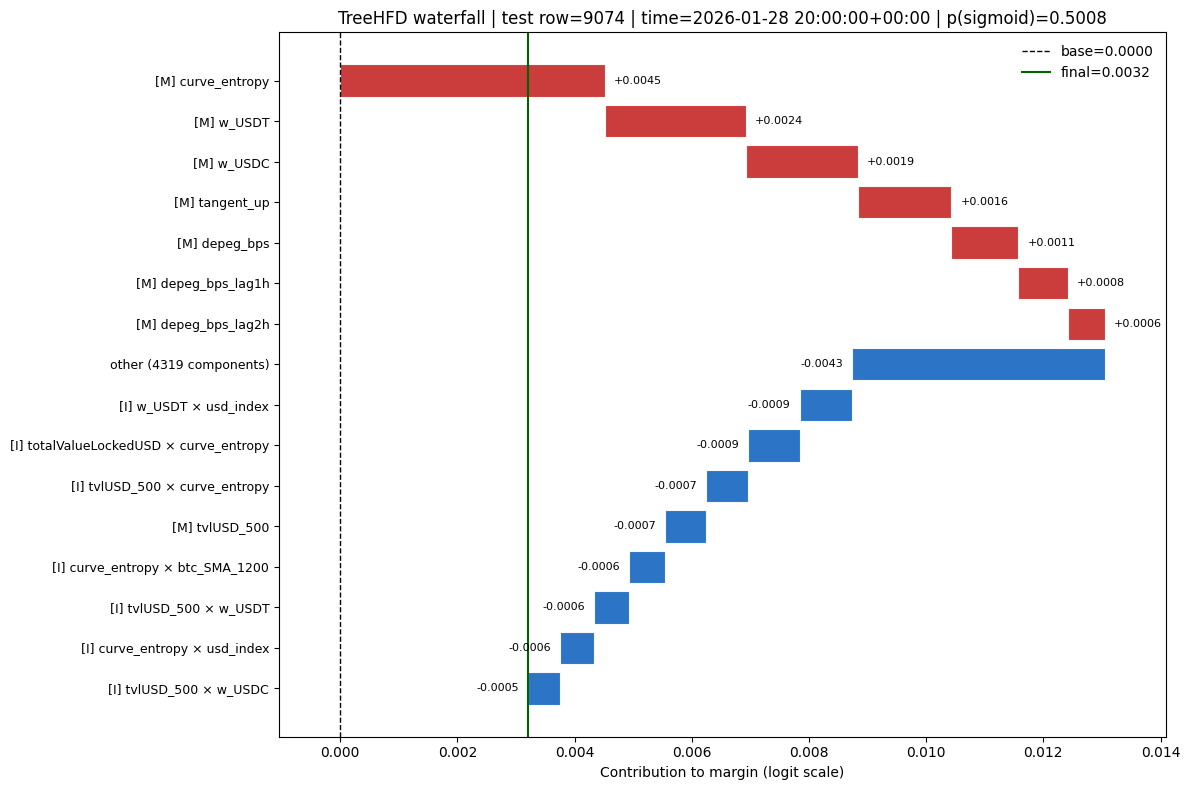

In [45]:
ranked = plot_hfd_waterfall_for_test_row(
    row_idx=9074,
    hfd_main_df=hfd,
    hfd_order2_np=hfd_int,
    interaction_labels_df=int_list,
    top_k=15,
    base_value=0.0)

In [39]:
hfdnod = hfd.drop('timestamp', axis=1)

In [42]:
(hfdnod.std()).sort_values(ascending=False).head(20)

hfd_main__curve_entropy                    0.002038
hfd_main__w_USDT                           0.000940
hfd_main__w_USDC                           0.000678
hfd_main__swap_count_100                   0.000451
hfd_main__eth_price_usd                    0.000391
hfd_main__depeg_bps                        0.000379
hfd_main__tangent_up                       0.000289
hfd_main__depeg_bps_lag1h                  0.000287
hfd_main__tick_width_24h_rolling_median    0.000239
hfd_main__Gegenbauer_0.1_deg3_vol24        0.000226
hfd_main__btc_vol_168                      0.000220
hfd_main__btc_ATR_24                       0.000207
hfd_main__depeg_bps_lag2h                  0.000205
hfd_main__usd_index                        0.000185
hfd_main__eth_RSI_24                       0.000168
hfd_main__swap_size_imbalance              0.000162
hfd_main__depeg_bps_lag3h                  0.000136
hfd_main__depeg_bps_lag4h                  0.000135
hfd_main__hhi_24h_rolling_mean             0.000135
hfd_main__Ge

In [21]:
import shap 

explainer = shap.TreeExplainer(xgb_rf)

In [24]:
shap_values = explainer.shap_values(X_test_np)

In [25]:
np.save('./lightning_logs/cv_model_comparison_2026-05-06_full_retraining/random_forest_alpha_0.1_fullfeatures_top2_cv_auc,top2_cv_auprc/artifacts/predictions/shap_values_test.npy', shap_values)

In [52]:
hfd_np = hfd.iloc[:,1:].values
feature_labels = FEATURES

Text(0, 0.5, 'E_odd importance')

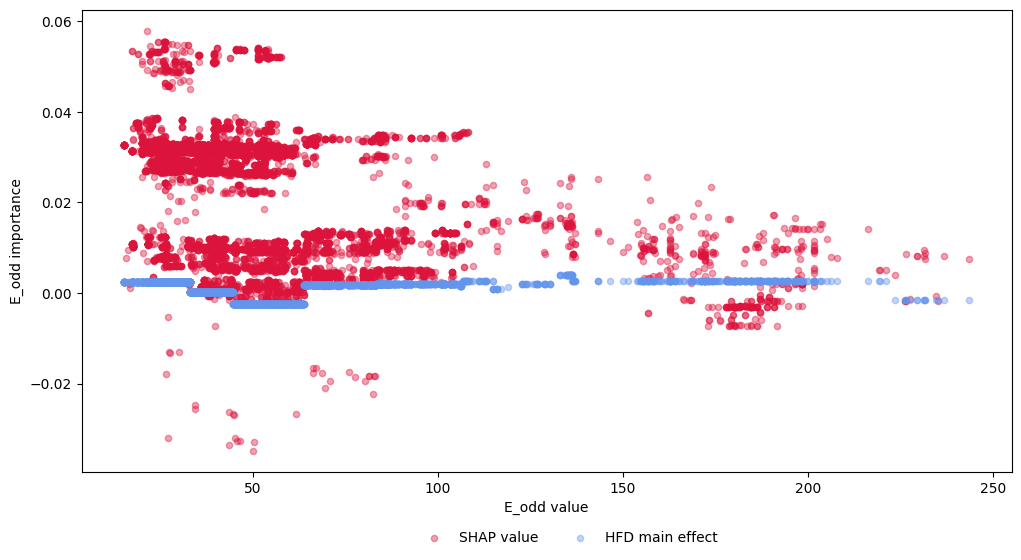

In [97]:
feature = "E_odd"
index = feature_labels.index(feature)
plt.figure(figsize=(12, 6))
plt.scatter(X_test_np[:, index], shap_values[:, index], alpha = 0.4, color = 'crimson', s = 20)
plt.scatter(X_test_np[:, index], hfd_np[:, index], alpha = 0.4, color = 'cornflowerblue', s = 20)
plt.legend(["SHAP value", "HFD main effect"], bbox_to_anchor=(.35, -0.1), ncols = 2, frameon = False, loc='upper left')
plt.xlabel(f"{feature} value")
plt.ylabel(f"{feature} importance")